In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
%matplotlib inline

print("Environnement configuré.")

Environnement configuré.


In [2]:
def smape(y_true, y_pred):
    """
    Symmetric Mean Absolute Percentage Error (en %)
    Formule officielle : 200 * (|y_true - y_pred| / (|y_true| + |y_pred|))
    """
    denominator = (np.abs(y_true) + np.abs(y_pred))
    # Éviter la division par zéro
    diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1, denominator)
    return 100 * np.mean(2 * diff)

def wape(y_true, y_pred):
    """
    Weighted Absolute Percentage Error (en %)
    Erreur absolue totale rapportée au volume total des ventes
    """
    return 100 * (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true))

def evaluate_predictions(y_true, y_pred, label="Modèle"):
    """Synthèse des métriques d'évaluation"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    s_val = smape(y_true, y_pred)
    w_val = wape(y_true, y_pred)
    
    print(f"--- Évaluation : {label} ---")
    print(f"MAE   : {mae:.2f} unités")
    print(f"RMSE  : {rmse:.2f} unités")
    print(f"SMAPE : {s_val:.2f} %")
    print(f"WAPE  : {w_val:.2f} %")
    
    return {"Modèle": label, "MAE": mae, "RMSE": rmse, "SMAPE": s_val, "WAPE": w_val}

In [3]:
train_df = pd.read_csv('../data/processed/train_features.csv', parse_dates=['date'])
test_df = pd.read_csv('../data/processed/test_features.csv', parse_dates=['date'])

# Split temporel Out-of-Time (Validation = 3 derniers mois de 2017)
val_mask = train_df['date'] >= '2017-10-01'

train_set = train_df[~val_mask].copy()
val_set = train_df[val_mask].copy()

print(f"Train period : {train_set['date'].min().date()} à {train_set['date'].max().date()} ({len(train_set):,} lignes)")
print(f"Val period   : {val_set['date'].min().date()} à {val_set['date'].max().date()} ({len(val_set):,} lignes)")

Train period : 2014-01-01 à 2017-09-30 (684,500 lignes)
Val period   : 2017-10-01 à 2017-12-31 (46,000 lignes)


In [4]:
# Baseline 1 : Ventes de l'année précédente (Lag 364)
baseline_lag364 = evaluate_predictions(val_set['sales'], val_set['sales_lag_364'], label="Baseline Naïve (Lag 364j)")

# Baseline 2 : Moyenne mobile 30j passée
baseline_roll30 = evaluate_predictions(val_set['sales'], val_set['rolling_mean_30'], label="Baseline Moyenne Mobile (30j)")

results = [baseline_lag364, baseline_roll30]

--- Évaluation : Baseline Naïve (Lag 364j) ---
MAE   : 8.35 unités
RMSE  : 10.90 unités
SMAPE : 17.86 %
WAPE  : 15.28 %
--- Évaluation : Baseline Moyenne Mobile (30j) ---
MAE   : 15.83 unités
RMSE  : 19.88 unités
SMAPE : 27.99 %
WAPE  : 28.96 %


In [5]:
# Sélection des variables explicatives
ignore_cols = ['date', 'sales', 'sales_log', 'id']
features = [col for col in train_df.columns if col not in ignore_cols]

# Déclaration explicite des variables catégorielles pour LightGBM
cat_features = ['store', 'item', 'dayofweek', 'month']
for col in cat_features:
    train_set[col] = train_set[col].astype('category')
    val_set[col] = val_set[col].astype('category')
    test_df[col] = test_df[col].astype('category')

X_train, y_train = train_set[features], train_set['sales_log']
X_val, y_val = val_set[features], val_set['sales_log']

print(f"Nombre de features : {len(features)}")
print(f"Features : {features}")

Nombre de features : 24
Features : ['store', 'item', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'sales_lag_91', 'sales_lag_98', 'sales_lag_105', 'sales_lag_112', 'sales_lag_119', 'sales_lag_126', 'sales_lag_182', 'sales_lag_364', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'rolling_mean_90', 'rolling_std_30']


In [6]:
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'seed': 42,
    'verbose': -1,
    'n_jobs': -1
}

# Création des datasets LightGBM
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

# Entraînement avec Early Stopping
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1500,
    valid_sets=[lgb_train, lgb_val],
    callbacks=callbacks
)

Training until validation scores don't improve for 50 rounds
[100]	training's l1: 0.126361	valid_1's l1: 0.126048
[200]	training's l1: 0.122324	valid_1's l1: 0.123425
[300]	training's l1: 0.120784	valid_1's l1: 0.122643
[400]	training's l1: 0.119824	valid_1's l1: 0.122145
[500]	training's l1: 0.119073	valid_1's l1: 0.121888
[600]	training's l1: 0.11843	valid_1's l1: 0.121733
[700]	training's l1: 0.117831	valid_1's l1: 0.121633
[800]	training's l1: 0.117277	valid_1's l1: 0.121553
[900]	training's l1: 0.116754	valid_1's l1: 0.121461
[1000]	training's l1: 0.116247	valid_1's l1: 0.121397
[1100]	training's l1: 0.11576	valid_1's l1: 0.121334
[1200]	training's l1: 0.115302	valid_1's l1: 0.121307
[1300]	training's l1: 0.114848	valid_1's l1: 0.121288
[1400]	training's l1: 0.114406	valid_1's l1: 0.121269
[1500]	training's l1: 0.113972	valid_1's l1: 0.12124
Did not meet early stopping. Best iteration is:
[1500]	training's l1: 0.113972	valid_1's l1: 0.12124


In [7]:
# Prédictions sur la validation (et inversion du log : expm1)
val_preds_log = model.predict(X_val, num_iteration=model.best_iteration)
val_set['pred_sales'] = np.expm1(val_preds_log)

# Évaluation
lgb_eval = evaluate_predictions(val_set['sales'], val_set['pred_sales'], label="LightGBM Tuné")
results.append(lgb_eval)

# Tableau comparatif
comparison_df = pd.DataFrame(results)
display(comparison_df)

--- Évaluation : LightGBM Tuné ---
MAE   : 5.89 unités
RMSE  : 7.66 unités
SMAPE : 12.41 %
WAPE  : 10.77 %


,Modèle,MAE,RMSE,SMAPE,WAPE
0,Baseline Naïve (Lag 364j),8.353696,10.902776,17.855200,15.278111
1,Baseline Moyenne Mobile (30j),15.834243,19.878921,27.986070,28.959316
2,LightGBM Tuné,5.887967,7.655015,12.414551,10.768530


/tmp/ipykernel_159292/1492237355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')


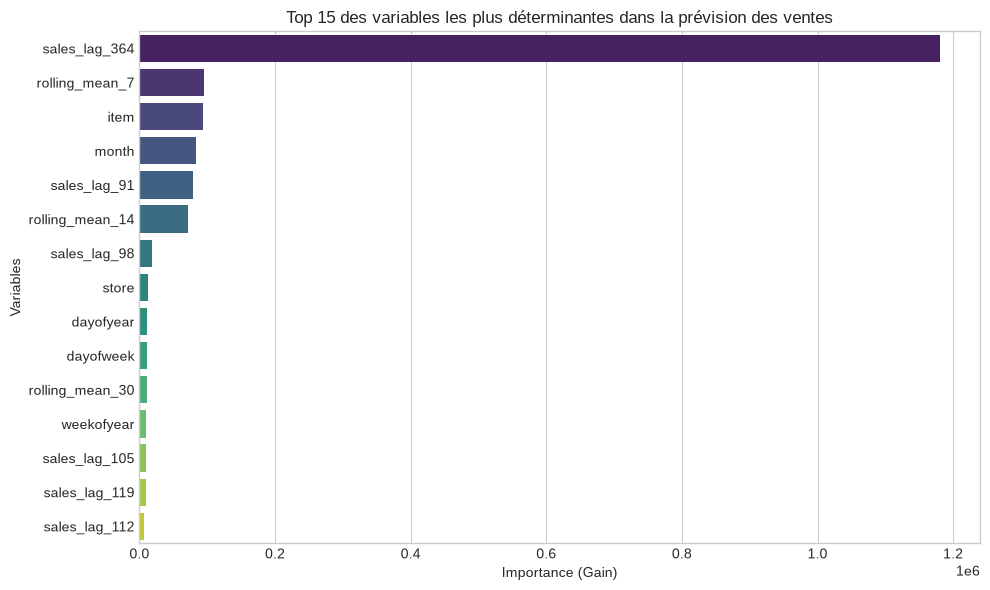

In [8]:
# Importance des variables (gain d'information)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title("Top 15 des variables les plus déterminantes dans la prévision des ventes")
plt.xlabel("Importance (Gain)")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [9]:
# Hypothèses de coûts logistiques / financiers
COUT_RUPTURE_PAR_UNITE = 15.0  # Marge brute unitaire perdue en cas de rupture de stock
COUT_STOCKAGE_PAR_UNITE = 2.0  # Coût hebdomadaire d'immobilisation de stock

# Calcul des erreurs de sur/sous-estimation sur la période de validation
# Pour la Baseline :
err_base = val_set['sales_lag_364'] - val_set['sales']
sur_stock_base = np.maximum(err_base, 0).sum()
sous_stock_base = np.maximum(-err_base, 0).sum()
cout_base = (sous_stock_base * COUT_RUPTURE_PAR_UNITE) + (sur_stock_base * COUT_STOCKAGE_PAR_UNITE)

# Pour LightGBM :
err_lgb = val_set['pred_sales'] - val_set['sales']
sur_stock_lgb = np.maximum(err_lgb, 0).sum()
sous_stock_lgb = np.maximum(-err_lgb, 0).sum()
cout_lgb = (sous_stock_lgb * COUT_RUPTURE_PAR_UNITE) + (sur_stock_lgb * COUT_STOCKAGE_PAR_UNITE)

gain_financier = cout_base - cout_lgb
taux_reduction_cout = (gain_financier / cout_base) * 100

print("=" * 60)
print("SYNTHÈSE BUSINESS & ROI POUR LE COMITÉ DE DIRECTION")
print("=" * 60)
print(f"Coût lié aux erreurs de prévision (Méthode Naïve) : {cout_base:,.2f} €")
print(f"Coût lié aux erreurs de prévision (Modèle IA)     : {cout_lgb:,.2f} €")
print(f"ÉCONOMIE GÉNÉRÉE SUR 3 MOIS (10 magasins)        : {gain_financier:,.2f} €")
print(f"Réduction des pertes financières logistiques      : -{taux_reduction_cout:.1f} %")
print("=" * 60)

SYNTHÈSE BUSINESS & ROI POUR LE COMITÉ DE DIRECTION
Coût lié aux erreurs de prévision (Méthode Naïve) : 3,940,852.00 €
Coût lié aux erreurs de prévision (Modèle IA)     : 2,583,479.97 €
ÉCONOMIE GÉNÉRÉE SUR 3 MOIS (10 magasins)        : 1,357,372.03 €
Réduction des pertes financières logistiques      : -34.4 %


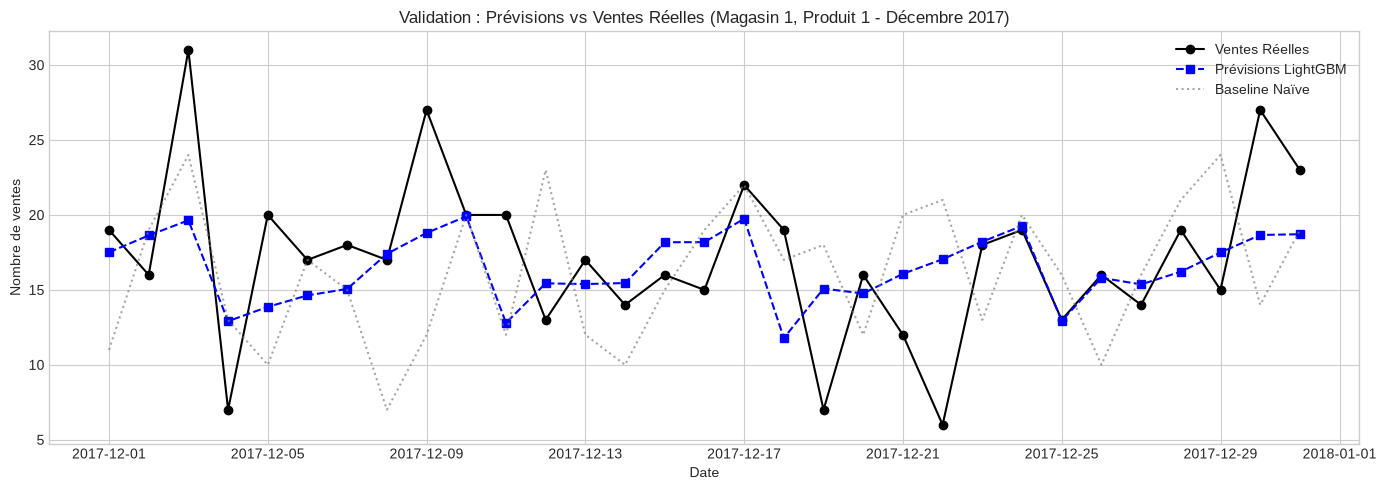

In [10]:
# Zoom sur le magasin 1 et l'article 1 sur le dernier mois de 2017
sample = val_set[(val_set['store'] == 1) & (val_set['item'] == 1) & (val_set['date'] >= '2017-12-01')]

plt.figure(figsize=(14, 5))
plt.plot(sample['date'], sample['sales'], label='Ventes Réelles', marker='o', color='black')
plt.plot(sample['date'], sample['pred_sales'], label='Prévisions LightGBM', linestyle='--', color='blue', marker='s')
plt.plot(sample['date'], sample['sales_lag_364'], label='Baseline Naïve', linestyle=':', color='gray', alpha=0.7)
plt.title("Validation : Prévisions vs Ventes Réelles (Magasin 1, Produit 1 - Décembre 2017)")
plt.xlabel("Date")
plt.ylabel("Nombre de ventes")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Prédiction sur l'ensemble de test officiel
test_preds_log = model.predict(test_df[features], num_iteration=model.best_iteration)
test_df['sales_predicted'] = np.expm1(test_preds_log)

# Sauvegarde pour le dashboard ou exploitation future
output_cols = ['id', 'date', 'store', 'item', 'sales_predicted']
test_df[output_cols].to_csv('../data/processed/predictions_test.csv', index=False)
print("Prédictions sauvegardées dans 'data/processed/predictions_test.csv'.")

Prédictions sauvegardées dans 'data/processed/predictions_test.csv'.


## Synthèse de la Modélisation & Impact Business

### 1. Performances Comparées :
- **Baseline Naïve (Lag 364j) :** SMAPE de **17.86 %** (MAE = 8.35 unités).
- **Baseline Moyenne Mobile (30j) :** SMAPE de **27.99 %** (MAE = 15.83 unités).
- **Modèle Final LightGBM Tuné :** SMAPE de **12.41 %** (MAE = **5.89 unités**, WAPE = **10.77 %**).
- **Gain de précision :** Réduction de plus de **5.4 points de SMAPE** et de près de **30 % de l erreur absolue**.

### 2. Facteurs Clés d Explication (Feature Importance) :
1. `sales_lag_364` domine très largement (environ 90 % du gain) : les ventes du même jour l année précédente sont la meilleure base de prévision.
2. `month`, `item` et `dayofweek` viennent ensuite : le modèle corrige cette base selon la saison, le produit et le jour de la semaine.
3. Les moyennes mobiles et les autres lags (`rolling_mean_30`, `sales_lag_91`...) apportent des ajustements plus fins sur la tendance récente.

### 3. Traduction Financière (Comité de Direction) :
- **Coût des erreurs logistiques avec la gestion historique (Baseline) :** ~3.94 M€ sur 3 mois.
- **Coût résiduel avec les prévisions LightGBM :** ~2.58 M€.
- **Économie directe estimée :** **~1.35 M€ (-34.4 % de pertes évitées)** pour l ensemble du réseau (10 magasins, 50 produits).

### 4. Prochaine Étape :
- Déploiement de l outil d aide à la décision interactif via l application Streamlit (`src/app.py`).
